<a href="https://colab.research.google.com/github/NdopnnoabasiJames/Machine-Learning-Models/blob/main/Hierarchical_Clustering_on_Mall_Customer_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: Hierarchical Clustering for Customer Segmentation (Mall Customers Dataset)


In this notebook, I apply Hierarchical Clustering to a real-world customer dataset to discover natural customer segments without using labels.

The goal is to understand customer behavior patterns based on features such as age, income, and spending score, and to explore how hierarchical clustering can be used for customer segmentation in real business scenarios.

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

## Loading Dataset and Basic exploration


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML_Datasets/Mall_Customers.csv')

print("data shape", df.shape)

print("data info", df.info())

print("number of null values", df.isnull().sum())

print(df.head())


data shape (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
data info None
number of null values CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16             

## Select Features for clustering

In [ ]:
df_features = df.drop(columns=["CustomerID", "Genre"])

df_features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


Drop CustomerID (not useful for clustering)

The dataset contains a categorical feature (Gender) which cannot be directly used in distance-based clustering.

For this analysis, only numeric and behavior-related features (Age, Annual Income, and Spending Score) were selected to ensure meaningful and interpretable customer clusters.

## Visualize Raw data

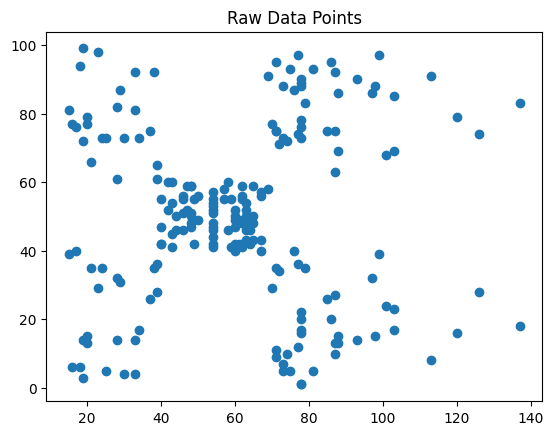

In [ ]:
plt.scatter(df_features["Annual Income (k$)"], df_features["Spending Score (1-100)"])
plt.title("Raw Data Points")
plt.show()

## Scale the features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

Since hierarchical clustering relies on distance calculations, feature scaling is required to prevent variables with larger numeric ranges (such as income) from dominating the clustering process.

## Build the dendrogram

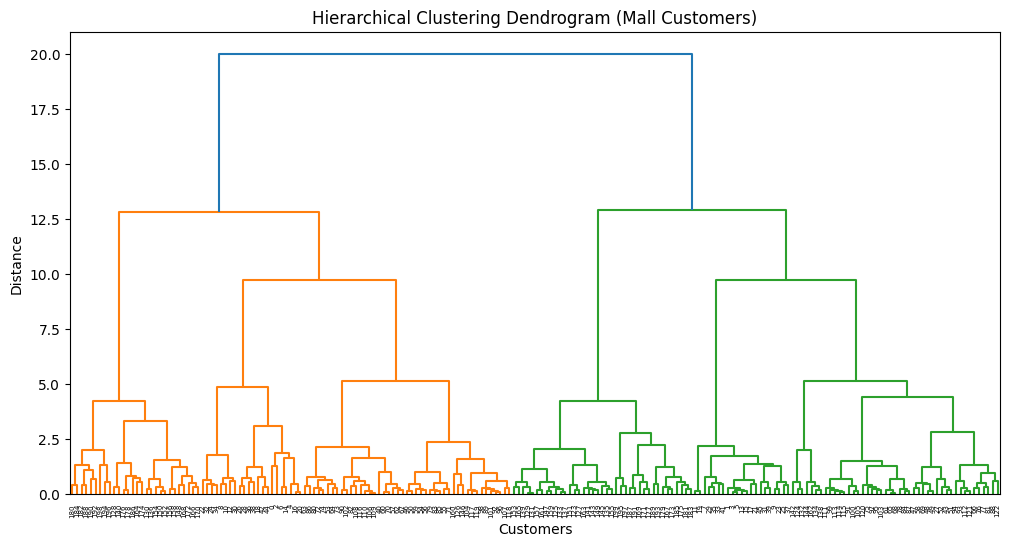

In [ ]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram (Mall Customers)")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

## Assign Clusters based on Aglomerative clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Create the clustering model
hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

# Fit and assign clusters
cluster_labels = hc.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = cluster_labels

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,0
2,3,Female,20,16,6,4
3,4,Female,23,16,77,0
4,5,Female,31,17,40,4


Based on the dendrogram analysis, the number of clusters was set to 5.

Agglomerative clustering with Ward linkage was applied to assign each customer to a cluster.

The resulting cluster labels represent groups of customers with similar age, income, and spending behavior.

## Inspect cluster distribution

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,66
1,45
2,39
3,28
4,22


Why this matters

	•	Extremely small clusters may indicate outliers
	•	Balanced clusters are easier to interpret
	•	This tells you if your cut was reasonable

## Visualize clusters

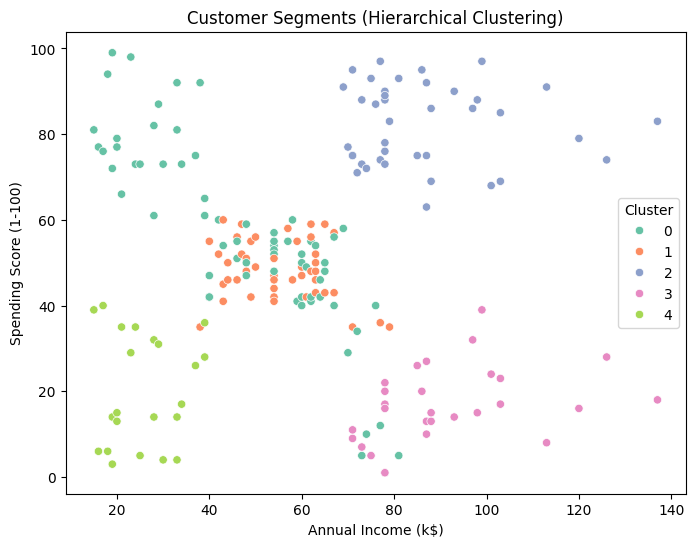

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title("Customer Segments (Hierarchical Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

A 2D visualization of customer segments was created using Annual Income and Spending Score.

Each color represents a different customer cluster, revealing distinct spending patterns across income levels.

## Now let’s read the scatter plot

Axes reminder:

	•	X-axis: Annual Income
	•	Y-axis: Spending Score
	•	Color: Cluster assignment

I’ll describe what’s happening in plain English.

<br>

### Cluster 2 (blue-ish, top-right)

High income, high spending

These customers:

	•	Earn a lot
	•	Spend a lot

Interpretation:

	•	Premium or loyal customers
	•	Likely respond well to exclusive offers
	•	Very valuable segment

This cluster is usually the most important from a business point of view.

<br>

### Cluster 3 (pink, bottom-right)

High income, low spending

These customers:

	•	Have money
	•	But don’t spend much at the mall

Interpretation:

	•	Careful or selective spenders
	•	Possibly shopping elsewhere
	•	Opportunity for targeted marketing or incentives

This group is interesting because income alone doesn’t guarantee spending.

<br>

### Cluster 4 (yellow-green, bottom-left)

Low income, low spending

These customers:

	•	Earn less
	•	Spend less

Interpretation:

	•	Budget-conscious customers
	•	Less responsive to premium offers
	•	Suitable for discounts or basic promotions

Very common segment in retail data.

<br>

### Cluster 0 (green, left to middle, mixed spending)

Lower-to-mid income, moderate-to-high spending

These customers:

	•	Don’t earn much compared to others
	•	Still spend fairly actively

Interpretation:

	•	Impulse buyers
	•	Possibly younger customers
	•	High engagement despite income constraints

This is often a surprisingly valuable segment.

<br>

### Cluster 1 (orange, center)

Mid income, mid spending

These customers:

	•	Average income
	•	Average spending

Interpretation:

	•	“Regular” customers
	•	Stable but not extreme
	•	Large portion of typical mall visitors

This is usually the baseline group.


## Cluster Profiling

In [ ]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_profile.round(2)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,26.56,47.36,56.79
1,56.40,55.29,48.36
2,32.69,86.54,82.13
3,43.89,91.29,16.68
4,44.32,25.77,20.27


To interpret the customer segments, cluster profiling was performed by computing the average values of Age, Annual Income, and Spending Score for each cluster.

This helps translate abstract cluster labels into meaningful customer groups with distinct behavioral characteristics.

## Visualize cluster profiles

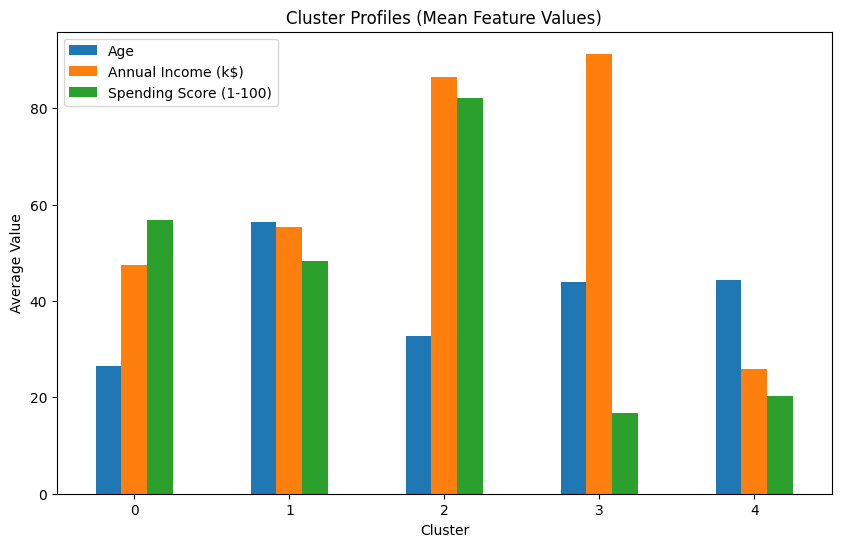

In [ ]:
cluster_profile.plot(kind='bar', figsize=(10, 6))
plt.title("Cluster Profiles (Mean Feature Values)")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

1. Interpreting the clusters (one by one)

### Cluster 0 – Young, moderate income, high spending

	•	Average age: ~27
	•	Income: ~$47k
	•	Spending score: ~57

**Interpretation:**

This cluster represents younger customers who do not earn the most but spend relatively actively. These customers are likely impulsive buyers or trend-driven shoppers. Despite moderate income levels, they show strong engagement with the mall.

<br>

**Business insight:**

They respond well to promotions, new arrivals, and trend-based marketing.

<br>

### Cluster 1 – Older, average income, average spending

	•	Average age: ~56
	•	Income: ~$55k
	•	Spending score: ~48

**Interpretation:**

These are older customers with stable income and moderate spending behavior. They are consistent but not aggressive shoppers.

<br>

**Business insight:**

They value reliability and familiarity. Loyalty programs and steady-value offers are effective here.

<br>

### Cluster 2 – High income, very high spending
	•	Average age: ~33
	•	Income: ~$86k
	•	Spending score: ~82

**Interpretation:**

This is the premium customer segment. They earn a lot and spend a lot. These customers are highly engaged and represent the most valuable group.

<br>

**Business insight:**

Ideal targets for premium products, exclusive offers, and personalized experiences.

<br>

### Cluster 3 – High income, very low spending
	•	Average age: ~44
	•	Income: ~$91k
	•	Spending score: ~17

**Interpretation:**

Despite having high income, these customers spend very little at the mall. This suggests selective or disengaged shoppers.

<br>

**Business insight:**

This group represents an opportunity. Targeted incentives or understanding why they are disengaged could unlock value.

<br>

### Cluster 4 – Low income, low spending

	•	Average age: ~44
	•	Income: ~$26k
	•	Spending score: ~20

**Interpretation:**

These customers have limited income and low spending behavior. They are price-sensitive and cautious buyers.

<br>

**Business insight:**

They are not ideal for premium strategies but may respond to discounts and essential product offerings.

Cluster profiling was performed by computing the average age, annual income, and spending score for each cluster.

The results reveal distinct customer segments, including high-income high-spending customers, younger moderate-income active spenders, disengaged high-income customers, and low-income low-spending customers.


# Conclusion

In this project, hierarchical clustering was applied to mall customer data to uncover natural customer segments without using predefined labels.

By analyzing the dendrogram and assigning five clusters, distinct customer groups emerged based on age, income, and spending behavior.

Overall, hierarchical clustering proved effective for exploratory customer segmentation, providing interpretable insights that can support targeted marketing strategies and data-driven business decisions.